<a href="https://colab.research.google.com/github/fluorescentlightpower/mifi_homework/blob/main/Letter_Classifier_%D0%92%D0%B2%D0%B5%D0%B4%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B2_%D0%B3%D0%BB%D1%83%D0%B1%D0%BE%D0%BA%D0%BE%D0%B5_%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Классификация букв по набору данных EMNIST Letters

Установка необходимых пакетов и импорты

In [1]:
! pip install torch torchvision tensorflow matplotlib numpy scikit-learn pillow

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import random
from google.colab import files
from PIL import Image
from pathlib import Path
from sklearn.metrics import confusion_matrix

# фиксация генераторов случайных чисел
torch.manual_seed(42)
tf.random.set_seed(42)
np.random.seed(42)

В исходном EMNIST Letters буквы расположены не как ожидается - буквы повернуты и отражены относительно вертикальной оси. Необходимо либо исправить исходный датасет, либо каждый раз преобразовывать буквы для инференса, иначе модель будет фактически обучаться на других "буквах", чем те, которые будут подаваться на распознавание. Ниже выполняется преобразование исходного датасета.

nn.CrossEntropyLoss() ожидает метки не с 1 по 26, а с 0 по 25, это тоже учитывается в преобразованиях

In [4]:
# преобразования для изображений
transform = transforms.Compose([
    transforms.ToTensor(),                           # PIL → тензор, значения [0, 1]
    transforms.Lambda(lambda x: x.transpose(1, 2)),     # поворот и отражение букв = транспонирование
    transforms.Lambda(lambda x: x.reshape(-1))          # (1,28,28) → (784)
])

# загрузка обучающей выборки
full_train = datasets.EMNIST(
    root='./data',                      # папка для сохранения данных
    split='letters',                    # буквенный датасет (не digits или balanced)
    train=True,                         # обучающая выборка
    download=True,                      # скачать, если нет локально
    transform=transform,                # применяем преобразования
    target_transform=lambda y: y - 1    # сдвиг меток для совместимости с nn.CrossEntropyLoss()
)

# загрузка тестовой выборки
test_dataset = datasets.EMNIST(
    root='./data',
    split='letters',
    train=False,             # тестовая выборка
    download=True,
    transform=transform,
    target_transform=lambda y: y - 1
)

print(f"Размер полной обучающей выборки: {len(full_train)}")
print(f"Размер оригинальной тестовой выборки: {len(test_dataset)}")

100%|██████████| 562M/562M [00:02<00:00, 222MB/s]


Размер полной обучающей выборки: 124800
Размер оригинальной тестовой выборки: 20800


In [5]:
# получение данных из PyTorch
X_train = (
    full_train
    .data.numpy()
    .transpose(0, 2, 1)             # full_train.data содержит исходные изображения без транспонирования
    .reshape(-1, 784)
    .astype('float32') / 255.0
)
y_train = full_train.targets.numpy().astype('int32') - 1

X_test = (
    test_dataset
    .data.numpy()
    .transpose(0, 2, 1)
    .reshape(-1, 784)
    .astype('float32') / 255.0
)
y_test = test_dataset.targets.numpy().astype('int32') - 1


print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (124800, 784), y_train: (124800,)
X_test: (20800, 784), y_test: (20800,)


Ниже отдельный тензор для отображения исходных букв при визуализациях

In [6]:
image, label = full_train[0]

print(f"Всего пикселей в изображении: {image.shape[0]}")

transform_raw = transforms.Compose([
    transforms.ToTensor(),                           # PIL → тензор, значения [0, 1]
    transforms.Lambda(lambda x: x.transpose(1, 2))
])

raw_train = datasets.EMNIST(
    root='./data',
    split='letters',
    train=True,
    download=True,
    transform=transform_raw
)

raw_test = datasets.EMNIST(
    root='./data',
    split='letters',
    train=False,
    download=True,
    transform=transform_raw
)

img, _ = raw_train[0]
print(f"Размеры изображения: {img.shape[1]} × {img.shape[2]}")

Всего пикселей в изображении: 784
Размеры изображения: 28 × 28


In [7]:
# Проверка минимального и максимального значения для пикселей
global_min = np.inf
global_max = -np.inf

for img, _ in full_train:
    global_min = min(global_min, img.min().item())
    global_max = max(global_max, img.max().item())

print(f"Минимум: {global_min}")
print(f"Максимум: {global_max}")

Минимум: 0.0
Максимум: 1.0


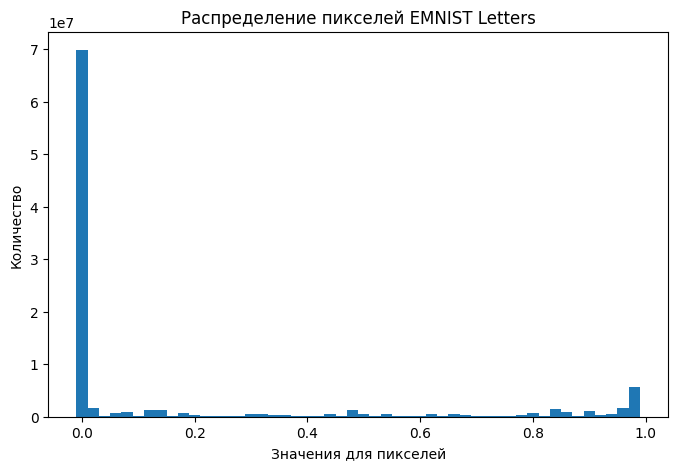

In [8]:
# Загрузчик
loader = DataLoader(full_train, batch_size=1024)

hist = np.zeros(50)
bins = np.linspace(0, 1, 51)

for images, _ in loader:
    h, _ = np.histogram(images.numpy(), bins=bins)
    hist += h

plt.figure(figsize=(8, 5))
plt.bar(bins[:-1], hist, width=1/50)
plt.xlabel("Значения для пикселей")
plt.ylabel("Количество")
plt.title("Распределение пикселей EMNIST Letters")
plt.show()

Большая часть изображений - черный фон, некоторое количество переходных пикселей на границах букв и белые пиксели в середине линий

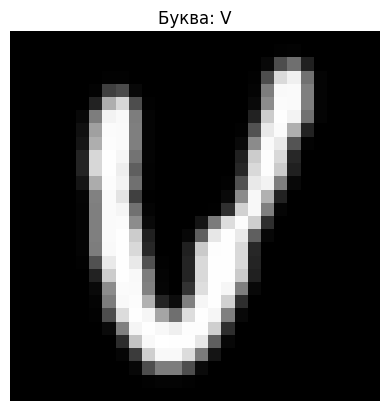

Минимум интенсивности: 0.0000, максимум интенсивности: 1.0000


In [9]:
# Случайный индекс - случайная буква
idx = random.randint(0, len(raw_train) - 1)

image, label = raw_train[idx]
letter = string.ascii_uppercase[label - 1]

plt.imshow(image.squeeze(0), cmap='gray')
plt.title(f"Буква: {letter}")
plt.axis('off')
plt.show()

print(f"Минимум интенсивности: {full_train[idx][0].numpy().min():.4f}, максимум интенсивности: {full_train[idx][0].numpy().max():.4f}")

Буквы распределены по классам в точности равномерно - минимум, максимум и среднее совпадают

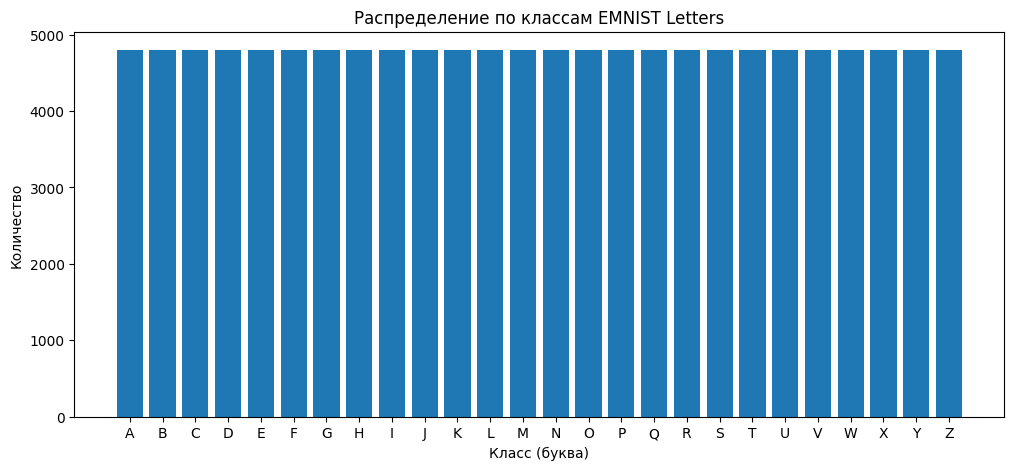

Минимум: 4800
Максимум: 4800
Среднее: 4800.0


In [10]:
loader = DataLoader(full_train, batch_size=1024)

counts = torch.zeros(26, dtype=torch.long)

for _, labels in loader:
    counts += torch.bincount(labels, minlength=26)

letters = list(string.ascii_uppercase)

plt.figure(figsize=(12, 5))
plt.bar(letters, counts.numpy())
plt.xlabel("Класс (буква)")
plt.ylabel("Количество")
plt.title("Распределение по классам EMNIST Letters")
plt.show()

print("Минимум:", counts.min().item())
print("Максимум:", counts.max().item())
print("Среднее:", counts.float().mean().item())

Вывод по 5 случайных изображений каждой буквы

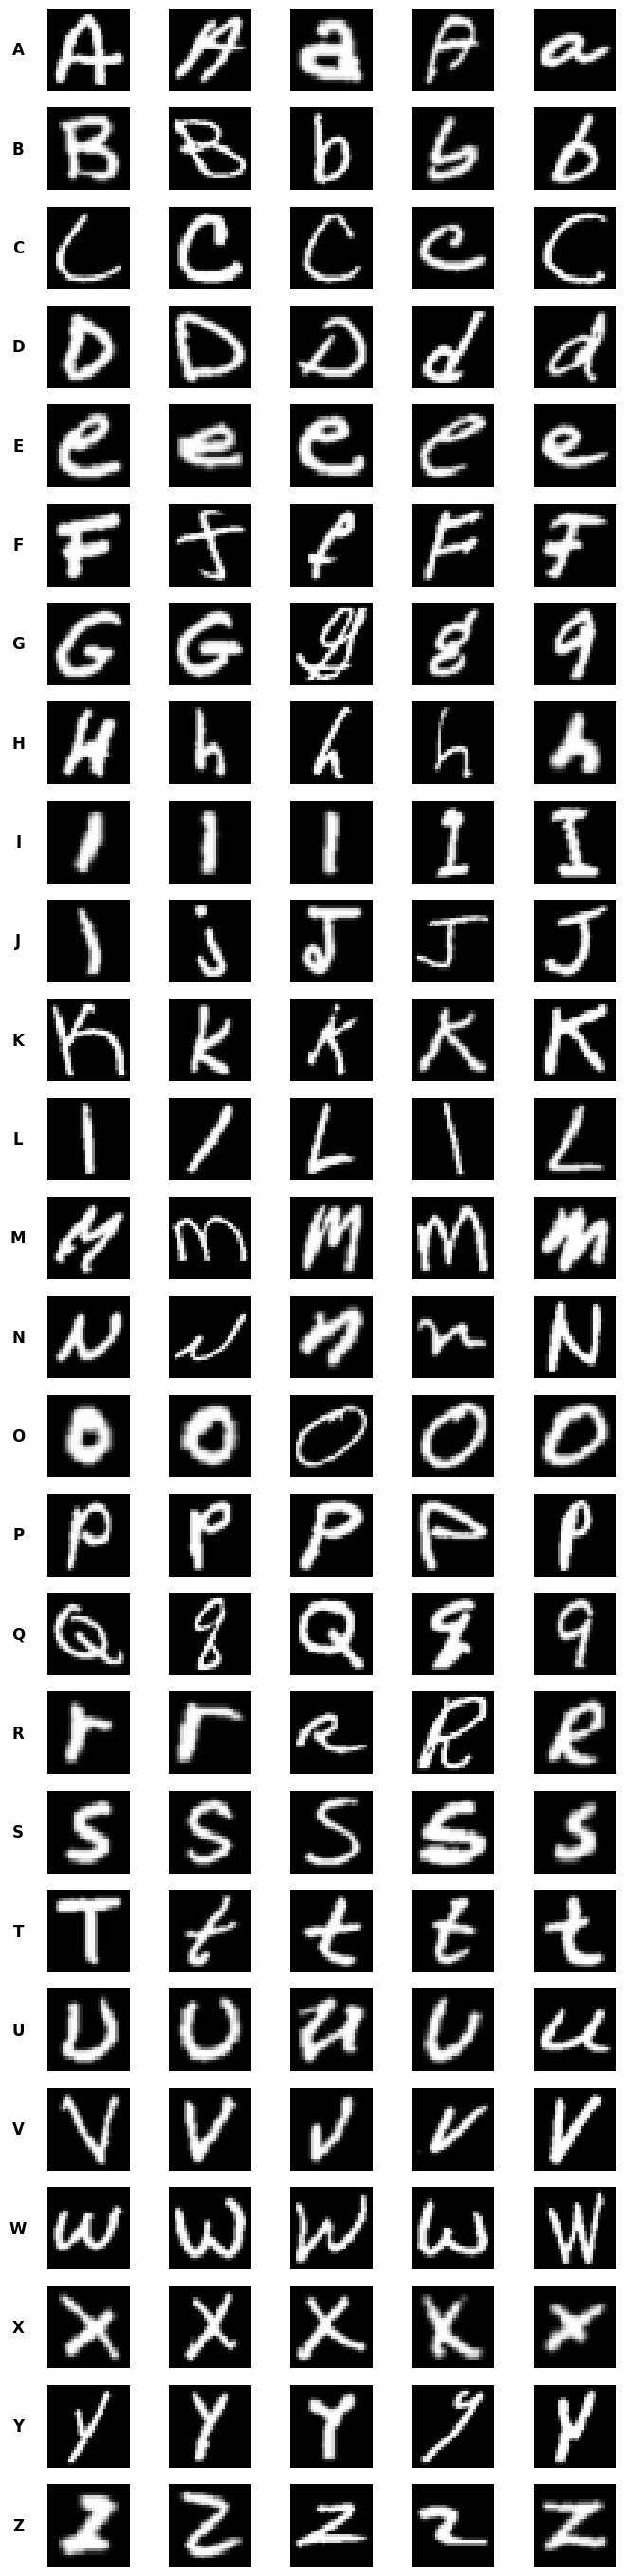

In [11]:
# Собираем индексы изображений для каждого класса

class_indices = {i: [] for i in range(1, 27)}

for idx, (_, label) in enumerate(raw_train):
    class_indices[label].append(idx)

# 26 строк (буквы), 5 столбцов (случайные примеры)
fig, axes = plt.subplots(26, 5, figsize=(8, 35))

for class_id in range(1, 27):

    # Случайные 5 изображений данного класса
    sample_indices = random.sample(class_indices[class_id], 5)

    for col, idx in enumerate(sample_indices):
        img, _ = raw_train[idx]

        axes[class_id - 1, col].imshow(
            img.squeeze(0),
            cmap='gray'
        )
        axes[class_id - 1, col].axis('off')

        # Подписываем букву слева
        if col == 0:
            axes[class_id - 1, col].text(
                -0.35, 0.5,
                string.ascii_uppercase[class_id - 1],
                transform=axes[class_id - 1, col].transAxes,
                fontsize=12,
                fontweight='bold',
                va='center',
                ha='center'
            )
plt.show()

Разделение исходной выборки для обучения на собственно обучающую и валидационную - PyTorch

In [12]:
train_size = int(0.9 * len(full_train))
val_size = len(full_train) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset_pt, val_dataset_pt = random_split(
    full_train,
    [train_size, val_size],
    generator=generator
)

train_idx, val_idx = train_dataset_pt.indices, val_dataset_pt.indices

print(f"Размер обучающей выборки: {len(train_dataset_pt)}")
print(f"Размер валидационной выборки: {len(val_dataset_pt)}")

Размер обучающей выборки: 112320
Размер валидационной выборки: 12480


Разделение исходной выборки для обучения на собственно обучающую и валидационную - Tensorflow, те же индексы

In [13]:
X_train_split = X_train[train_idx]
y_train_split = y_train[train_idx]

X_val = X_train[val_idx]
y_val = y_train[val_idx]

In [14]:
print(X_train_split.shape)
print(X_train_split.dtype)
print(np.min(X_train_split), np.max(X_train_split))
print(np.isnan(X_train_split).any())

(112320, 784)
float32
0.0 1.0
False


Загрузка данных более явно и кратко выглядит у Tensorflow. PyTorch требует конструировать отдельные трансформеры и лямбда-выражения. Неочевидным оказалось, что при загрузке данных из PyTorch в Tensorflow изображения опять нужно разворачивать

In [35]:
# Загрузчики PyTorch для каждого набора данных

batch_size = 64

train_loader = DataLoader(
    train_dataset_pt,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset_pt,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [36]:
# создание tf.data.Dataset

train_dataset_tf = tf.data.Dataset.from_tensor_slices((X_train_split, y_train_split))
train_dataset_tf = train_dataset_tf.shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_dataset_tf = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset_tf = val_dataset_tf.batch(batch_size)

test_dataset_tf = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset_tf = test_dataset_tf.batch(batch_size)

Классы-конструкторы для моделей

In [37]:
class MLPLetters_pt(nn.Module):
    def __init__(self, input_size=28*28*1, hidden_sizes=[512, 256, 128], num_classes=26, dropout_rate=0.3):
        super().__init__()
        layers = []
        prev_size = input_size
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            else:
                layers.append(nn.Identity())
            prev_size = hidden_size
        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [38]:
class MLPLetters_tf(tf.keras.Model):
    def __init__(self, input_size=28*28*1, hidden_sizes=[512, 256, 128], num_classes=26, dropout_rate=0.3):
        super().__init__()

        layers = []

        for hidden_size in hidden_sizes:
            layers.append(tf.keras.layers.Dense(hidden_size, activation='relu'))
            if dropout_rate > 0:
                layers.append(tf.keras.layers.Dropout(dropout_rate))
            else:
                layers.append(tf.keras.layers.Identity())

        layers.append(tf.keras.layers.Dense(num_classes))

        self.network = tf.keras.Sequential(layers)

    def call(self, x, training=False):
        return self.network(x, training=training)

Функция обучения моделей PyTorch с поиском и сохранением наилучших параметров

In [39]:
def train_pt_model(model, train_loader, val_loader, epochs=10, lr=0.001, patience=10, device='cpu', model_name="model"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_acc = 0.0
    patience_counter = 0

    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        # обучение
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # валидация
        model.eval()
        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

                _, predicted = outputs.max(1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()

        val_loss /= len(val_loader)
        accuracy = correct / total
        val_losses.append(val_loss)
        val_accuracies.append(accuracy)

        print(f"  {model_name} - Эпоха {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {accuracy:.4f}")

        if accuracy > best_val_acc:
            best_val_acc = accuracy
            patience_counter = 0
            torch.save(model.state_dict(), f'{model_name}.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  {model_name} - Ранняя остановка на эпохе {epoch+1}")
                break

    model.load_state_dict(torch.load(f'{model_name}.pth'))
    return model, train_losses, val_losses, val_accuracies, best_val_acc

Функция обучения моделей Tensorflow. В принципе даже функцию создавать необязательно, потому что Tensorflow реализует поиск наилучших параметров "внутри", но так удобнее задавать исходные гиперпараметры.

In [40]:
def train_tf_model(model, train_ds, val_ds, epochs=10, lr=0.001, patience=10, model_name="model"):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"]
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=patience,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f"{model_name}.h5",
            monitor="val_accuracy",
            save_best_only=True
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks
    )

    best_val_acc = max(history.history["val_accuracy"])

    return model, history, best_val_acc

Оценка моделей PyTorch

In [41]:
def evaluate_pt_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_confidences = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            probs = torch.softmax(outputs, dim=1)

            confidences, predicted = probs.max(dim=1)

            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            all_confidences.extend(confidences.cpu().numpy())

    return correct / total, all_preds, all_labels, all_confidences

In [42]:
# Определение доступного устройства - видеокарта или ЦП

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")

Устройство: cpu


## Модели без dropout

In [43]:
model_pt = MLPLetters_pt(dropout_rate=0)

model_pt, train_losses_pt, val_losses_pt, val_accuracies_pt, best_val_acc_pt = train_pt_model(
    model_pt,
    train_loader,
    val_loader,
    device=device,
    model_name="PyTorch"
)

  PyTorch - Эпоха 1/10 | Train Loss: 0.6705 | Val Loss: 0.3823 | Val Acc: 0.8760
  PyTorch - Эпоха 2/10 | Train Loss: 0.3242 | Val Loss: 0.3133 | Val Acc: 0.9004
  PyTorch - Эпоха 3/10 | Train Loss: 0.2571 | Val Loss: 0.2859 | Val Acc: 0.9104
  PyTorch - Эпоха 4/10 | Train Loss: 0.2208 | Val Loss: 0.2732 | Val Acc: 0.9128
  PyTorch - Эпоха 5/10 | Train Loss: 0.1941 | Val Loss: 0.2801 | Val Acc: 0.9130
  PyTorch - Эпоха 6/10 | Train Loss: 0.1740 | Val Loss: 0.2755 | Val Acc: 0.9154
  PyTorch - Эпоха 7/10 | Train Loss: 0.1561 | Val Loss: 0.2864 | Val Acc: 0.9202
  PyTorch - Эпоха 8/10 | Train Loss: 0.1429 | Val Loss: 0.2978 | Val Acc: 0.9142
  PyTorch - Эпоха 9/10 | Train Loss: 0.1308 | Val Loss: 0.3053 | Val Acc: 0.9150
  PyTorch - Эпоха 10/10 | Train Loss: 0.1229 | Val Loss: 0.3088 | Val Acc: 0.9181


In [44]:
model_tf = MLPLetters_tf(dropout_rate=0)

model_tf, history, best_val_acc_tf = train_tf_model(
    model_tf,
    train_dataset_tf,
    val_dataset_tf,
    model_name="Tensorflow"
)

Epoch 1/10
1754/1755 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7263 - loss: 0.9116

1755/1755 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.8183 - loss: 0.5837 - val_accuracy: 0.8900 - val_loss: 0.3450
Epoch 2/10
1752/1755 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8900 - loss: 0.3323

1755/1755 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8972 - loss: 0.3104 - val_accuracy: 0.8967 - val_loss: 0.3316
Epoch 3/10
1752/1755 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9109 - loss: 0.2598

1755/1755 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9156 - loss: 0.2474 - val_accuracy: 0.9068 - val_loss: 0.3122
Epoch 4/10
1753/1755 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9233 - loss: 0.2193

1755/1755 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - accuracy: 0.9256 - loss: 0.2120 - val_accuracy: 0.9078 - val_loss: 0.3033
Epoch 5/10
1753/1755 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9328 - loss: 0.1875

1755/1755 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9341 - loss: 0.1823 - val_accuracy: 0.9144 - val_loss: 0.2921
Epoch 6/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9396 - loss: 0.1630 - val_accuracy: 0.9125 - val_loss: 0.3112
Epoch 7/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9448 - loss: 0.1483 - val_accuracy: 0.9133 - val_loss: 0.3166
Epoch 8/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9485 - loss: 0.1365 - val_accuracy: 0.9135 - val_loss: 0.3337
Epoch 9/10
1753/1755 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9501 - loss: 0.1279

1755/1755 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9511 - loss: 0.1276 - val_accuracy: 0.9151 - val_loss: 0.3275
Epoch 10/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.9547 - loss: 0.1174 - val_accuracy: 0.9118 - val_loss: 0.3645


## Модели c dropout 0,3

In [45]:
model_pt_dropout = MLPLetters_pt(dropout_rate=0.3)

model_pt_dropout, train_losses_pt_d, val_losses_pt_d, val_accuracies_pt_d, best_val_acc_pt_d = train_pt_model(
    model_pt_dropout,
    train_loader,
    val_loader,
    device=device,
    model_name="PyTorch_dropout"
)

  PyTorch_dropout - Эпоха 1/10 | Train Loss: 0.9047 | Val Loss: 0.4205 | Val Acc: 0.8699
  PyTorch_dropout - Эпоха 2/10 | Train Loss: 0.5108 | Val Loss: 0.3483 | Val Acc: 0.8920
  PyTorch_dropout - Эпоха 3/10 | Train Loss: 0.4409 | Val Loss: 0.3194 | Val Acc: 0.8968
  PyTorch_dropout - Эпоха 4/10 | Train Loss: 0.4035 | Val Loss: 0.3092 | Val Acc: 0.9024
  PyTorch_dropout - Эпоха 5/10 | Train Loss: 0.3789 | Val Loss: 0.2893 | Val Acc: 0.9101
  PyTorch_dropout - Эпоха 6/10 | Train Loss: 0.3565 | Val Loss: 0.2815 | Val Acc: 0.9084
  PyTorch_dropout - Эпоха 7/10 | Train Loss: 0.3421 | Val Loss: 0.2794 | Val Acc: 0.9112
  PyTorch_dropout - Эпоха 8/10 | Train Loss: 0.3352 | Val Loss: 0.2691 | Val Acc: 0.9119
  PyTorch_dropout - Эпоха 9/10 | Train Loss: 0.3232 | Val Loss: 0.2553 | Val Acc: 0.9194
  PyTorch_dropout - Эпоха 10/10 | Train Loss: 0.3144 | Val Loss: 0.2613 | Val Acc: 0.9176


In [46]:
model_tf_dropout = MLPLetters_tf(dropout_rate=0.3)

model_tf_dropout, history_dropout, best_val_acc_tf_d = train_tf_model(
    model_tf_dropout,
    train_dataset_tf,
    val_dataset_tf,
    model_name="Tensorflow_dropout"
)

Epoch 1/10
1752/1755 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5948 - loss: 1.3596

1755/1755 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.7205 - loss: 0.9224 - val_accuracy: 0.8682 - val_loss: 0.4119
Epoch 2/10
1754/1755 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8246 - loss: 0.5641

1755/1755 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.8349 - loss: 0.5333 - val_accuracy: 0.8941 - val_loss: 0.3362
Epoch 3/10
1754/1755 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8526 - loss: 0.4703

1755/1755 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.8568 - loss: 0.4559 - val_accuracy: 0.9016 - val_loss: 0.3129
Epoch 4/10
1754/1755 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8670 - loss: 0.4186

1755/1755 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.8699 - loss: 0.4102 - val_accuracy: 0.9076 - val_loss: 0.2943
Epoch 5/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.8764 - loss: 0.3885 - val_accuracy: 0.9067 - val_loss: 0.2973
Epoch 6/10
1753/1755 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8816 - loss: 0.3687

1755/1755 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - accuracy: 0.8839 - loss: 0.3633 - val_accuracy: 0.9146 - val_loss: 0.2764
Epoch 7/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.8879 - loss: 0.3509 - val_accuracy: 0.9131 - val_loss: 0.2798
Epoch 8/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.8912 - loss: 0.3354 - val_accuracy: 0.9143 - val_loss: 0.2778
Epoch 9/10
1752/1755 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8950 - loss: 0.3281

1755/1755 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.8958 - loss: 0.3242 - val_accuracy: 0.9171 - val_loss: 0.2783
Epoch 10/10
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.8955 - loss: 0.3196 - val_accuracy: 0.9147 - val_loss: 0.2690


In [47]:
test_acc_pt, preds_pt, labels_pt, conf_pt = evaluate_pt_model(model_pt, test_loader, device)

In [48]:
test_acc_pt_d, preds_pt_d, labels_pt_d, conf_pt_d = evaluate_pt_model(model_pt_dropout, test_loader, device)

In [49]:
logits_tf = model_tf.predict(test_dataset_tf)
probs_tf = tf.nn.softmax(logits_tf, axis=1).numpy()

preds_tf = np.argmax(probs_tf, axis=1)
conf_tf = np.max(probs_tf, axis=1)
labels_tf = np.concatenate([y.numpy() for _, y in test_dataset_tf])

test_acc_tf = np.mean(preds_tf == labels_tf)

train_losses_tf = history.history["loss"]
val_losses_tf = history.history["val_loss"]
val_accuracies_tf = history.history["val_accuracy"]

325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [50]:
logits_tf_d = model_tf_dropout.predict(test_dataset_tf)
probs_tf_d = tf.nn.softmax(logits_tf_d, axis=1).numpy()

preds_tf_d = np.argmax(probs_tf_d, axis=1)
conf_tf_d = np.max(probs_tf_d, axis=1)

test_acc_tf_d = np.mean(preds_tf_d == labels_tf)

train_losses_tf_d = history_dropout.history["loss"]
val_losses_tf_d = history_dropout.history["val_loss"]
val_accuracies_tf_d = history_dropout.history["val_accuracy"]

325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [51]:
print(f"Точность PyTorch:      {test_acc_pt:.4f} ({test_acc_pt*100:.2f}%)")
print(f"Точность Tensorflow:   {test_acc_tf:.4f} ({test_acc_tf*100:.2f}%)")
print(f"Точность PyTorch с dropout:      {test_acc_pt_d:.4f} ({test_acc_pt*100:.2f}%)")
print(f"Точность Tensorflow с dropout:   {test_acc_tf_d:.4f} ({test_acc_tf*100:.2f}%)")

Точность PyTorch:      0.9101 (91.01%)
Точность Tensorflow:   0.9124 (91.24%)
Точность PyTorch с dropout:      0.9113 (91.01%)
Точность Tensorflow с dropout:   0.9103 (91.24%)


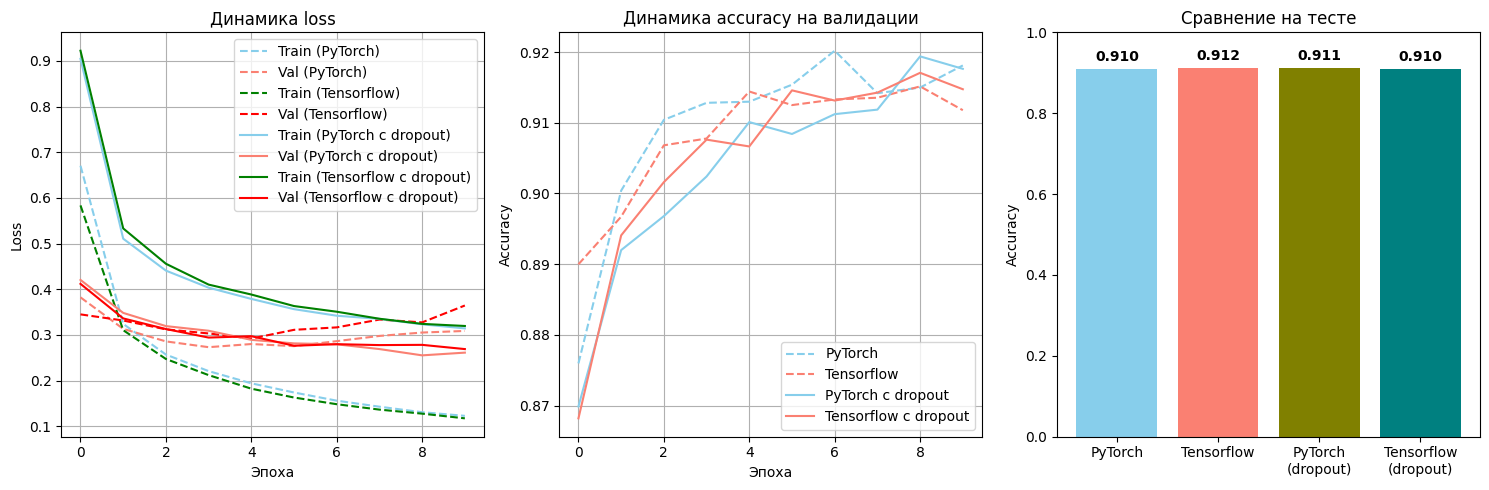

In [52]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses_pt, color='skyblue', ls='--', label='Train (PyTorch)')
plt.plot(val_losses_pt, color='salmon', ls='--', label='Val (PyTorch)')
plt.plot(train_losses_tf, color='green', ls='--', label='Train (Tensorflow)')
plt.plot(val_losses_tf, color='red', ls='--', label='Val (Tensorflow)')
plt.plot(train_losses_pt_d, color='skyblue', label='Train (PyTorch с dropout)')
plt.plot(val_losses_pt_d, color='salmon', label='Val (PyTorch с dropout)')
plt.plot(train_losses_tf_d, color='green', label='Train (Tensorflow с dropout)')
plt.plot(val_losses_tf_d, color='red', label='Val (Tensorflow с dropout)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.title('Динамика loss')

plt.subplot(1, 3, 2)
plt.plot(val_accuracies_pt, color='skyblue', ls='--', label='PyTorch')
plt.plot(val_accuracies_tf, color='salmon', ls='--', label='Tensorflow')
plt.plot(val_accuracies_pt_d, color='skyblue', label='PyTorch с dropout')
plt.plot(val_accuracies_tf_d, color='salmon', label='Tensorflow с dropout')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.title('Динамика accuracy на валидации')

plt.subplot(1, 3, 3)
methods = ['PyTorch', 'Tensorflow', 'PyTorch\n(dropout)', 'Tensorflow\n(dropout)']
accuracies = [test_acc_pt, test_acc_tf, test_acc_pt_d, test_acc_tf_d]
colors = ['skyblue', 'salmon', 'olive', 'teal']
bars = plt.bar(methods, accuracies, color=colors)
plt.ylabel('Accuracy')
plt.title('Сравнение на тесте')
plt.ylim(0, 1)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{acc:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Добавление слоев Dropout не привело к заметному изменению качества классификации. Вероятно, модель не испытывает существенного переобучения благодаря достаточно большому объему обучающей выборки EMNIST Letters и умеренному числу параметров сети. Различия в accuracy между вариантами с Dropout и без него не позволяют сделать вывод о значимом влиянии регуляризации на итоговое качество модели. Дальше метрики оцениваются на моделях с Dropout, так как переобучение все же заметно на валидационной выборке в моделях без Dropout (потери на val заметно больше потерь на train)

Tensorflow обучается заметно быстрее PyTorch, а также гораздо компактнее в реализации - не требуется сложных функций для обучения и оценки качества Tensorflow.

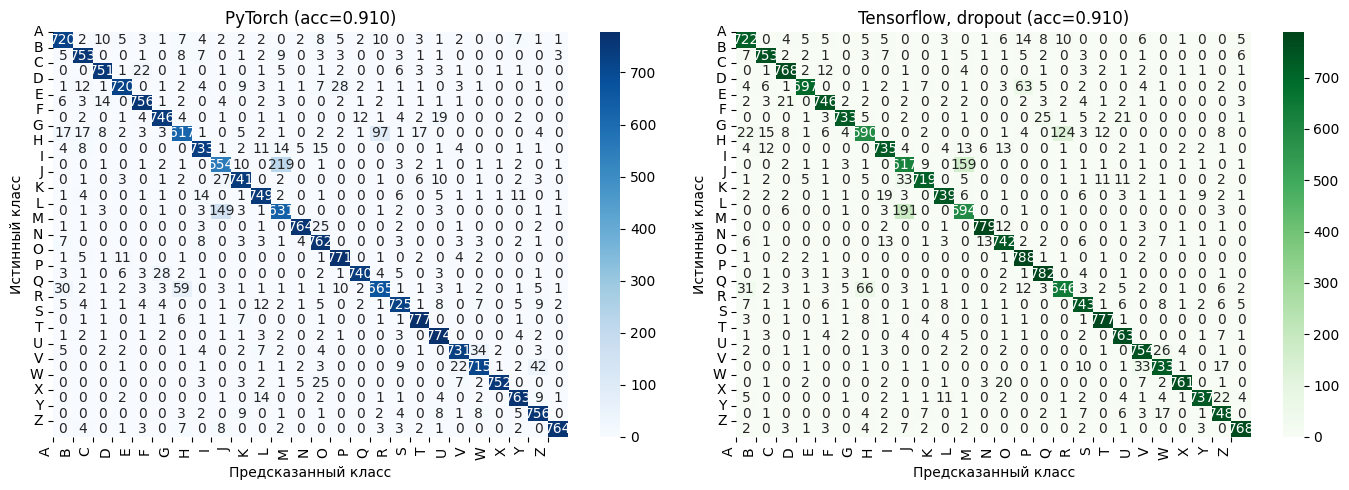

In [53]:
letters = [chr(ord('A') + i) for i in range(26)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_pt = confusion_matrix(labels_pt, preds_pt)
sns.heatmap(cm_pt, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_xlabel('Предсказанный класс')
axes[0].set_ylabel('Истинный класс')
axes[0].set_title(f'PyTorch (acc={test_acc_pt:.3f})')
axes[0].set_xticks(range(26))
axes[0].set_yticks(range(26))
axes[0].set_xticklabels(letters, rotation=90, ha='right')
axes[0].set_yticklabels(letters)

cm_tf_d = confusion_matrix(labels_tf, preds_tf_d)
sns.heatmap(cm_tf_d, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')
axes[1].set_title(f'Tensorflow, dropout (acc={test_acc_tf_d:.3f})')
axes[1].set_xticks(range(26))
axes[1].set_yticks(range(26))
axes[1].set_xticklabels(letters, rotation=90, ha='right')
axes[1].set_yticklabels(letters)

plt.tight_layout()
plt.show()

Функция вывода самых распространенных ошибок классификации

In [54]:
def top_confusions(labels, preds, top_n=5):
    cm = confusion_matrix(labels, preds)

    # главная диагональ (правильные ответы) нужно занулить
    np.fill_diagonal(cm, 0)

    letters = [chr(ord('A') + i) for i in range(26)]

    errors = []

    for true_class in range(cm.shape[0]):
        for pred_class in range(cm.shape[1]):
            count = cm[true_class, pred_class]

            if count > 0:
                errors.append(
                    (
                        letters[true_class],
                        letters[pred_class],
                        int(count)
                    )
                )

    errors.sort(key=lambda x: x[2], reverse=True)

    return errors[:top_n]

In [55]:
top5 = top_confusions(labels_pt, preds_pt_d)

for true_letter, pred_letter, count in top5:
    print(f"{true_letter} распознана как {pred_letter}: {count}")

I распознана как L: 294
G распознана как Q: 146
L распознана как I: 93
D распознана как O: 56
Q распознана как G: 43


In [56]:
top5 = top_confusions(labels_tf, preds_tf_d)

for true_letter, pred_letter, count in top5:
    print(f"{true_letter} распознана как {pred_letter}: {count}")

L распознана как I: 191
I распознана как L: 159
G распознана как Q: 124
Q распознана как G: 66
D распознана как O: 63


У моделей очень похожие ошибки, почти те же буквы вызывают сложности при классификации. Небольшое различие - PyTorch чаще путает Q-G, а Tensorflow чаще D-O

Функция визуализации ошибочно классифицированных букв. Выводит случайные примеры

In [57]:
def show_misclassified_from_raw(raw_dataset, labels, preds, confidences, n_examples=15, random=False):
    labels = np.array(labels)
    preds = np.array(preds)
    confidences = np.array(confidences)

    error_indices = np.where(labels != preds)[0]

    print(f"Всего ошибок: {len(error_indices)}")

    if random:
        selected_indices = np.random.choice(
            error_indices,
            size=min(n_examples, len(error_indices)),
            replace=False
        )
    else:
        selected_indices = error_indices[:n_examples]

    rows = int(np.ceil(len(selected_indices) / 5))
    cols = 5

    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, idx in zip(axes, selected_indices):
        img, _ = raw_dataset[idx]

        img = img.squeeze().numpy()

        true_letter = chr(ord("A") + labels[idx])
        pred_letter = chr(ord("A") + preds[idx])
        conf = confidences[idx]

        ax.imshow(img, cmap="gray")
        ax.set_title(
            f"Истинная буква: {true_letter}\n"
            f"Определена как: {pred_letter}\n"
            f"с вероятностью: {conf:.3f}"
        )
        ax.axis("off")

    for ax in axes[len(selected_indices):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Всего ошибок: 1844


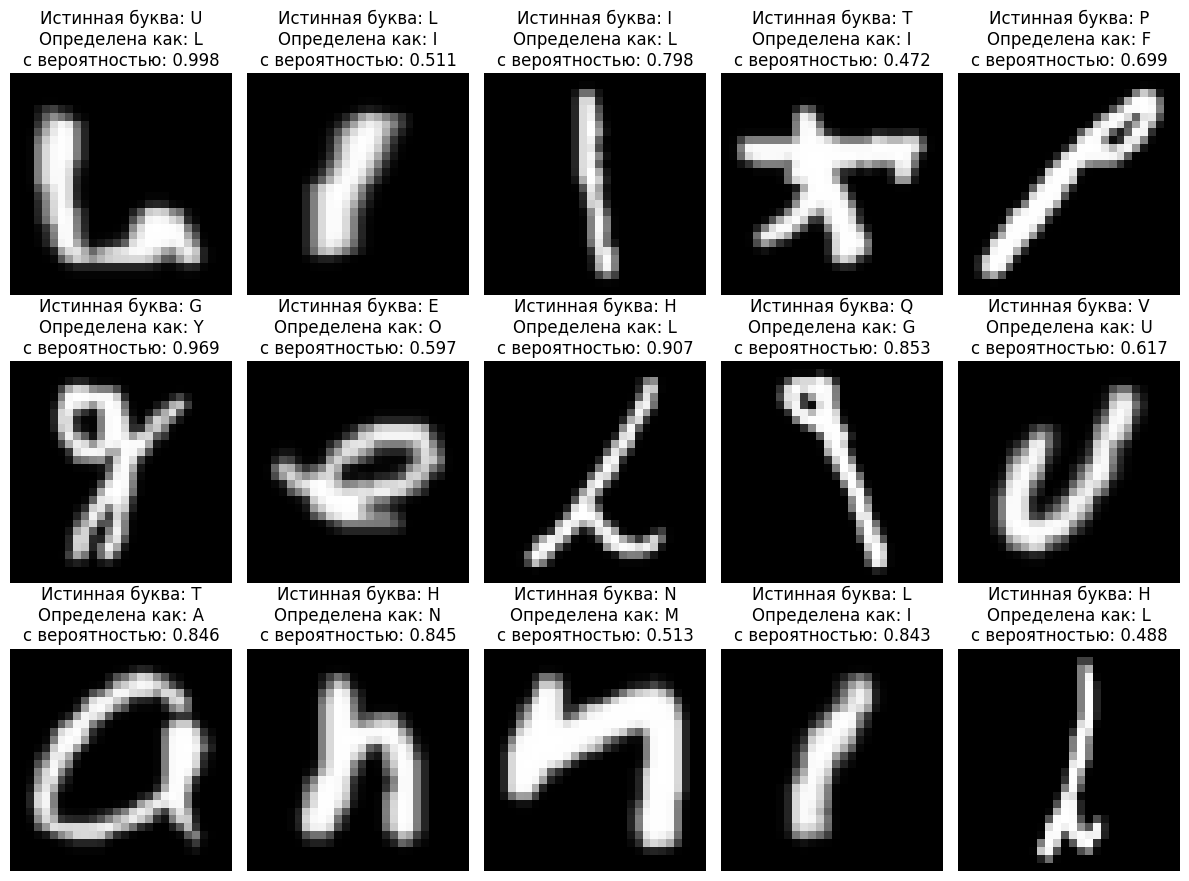

In [58]:
show_misclassified_from_raw(
    raw_test,
    labels_pt,
    preds_pt_d,
    conf_pt,
    random=True
)

Всего ошибок: 1866


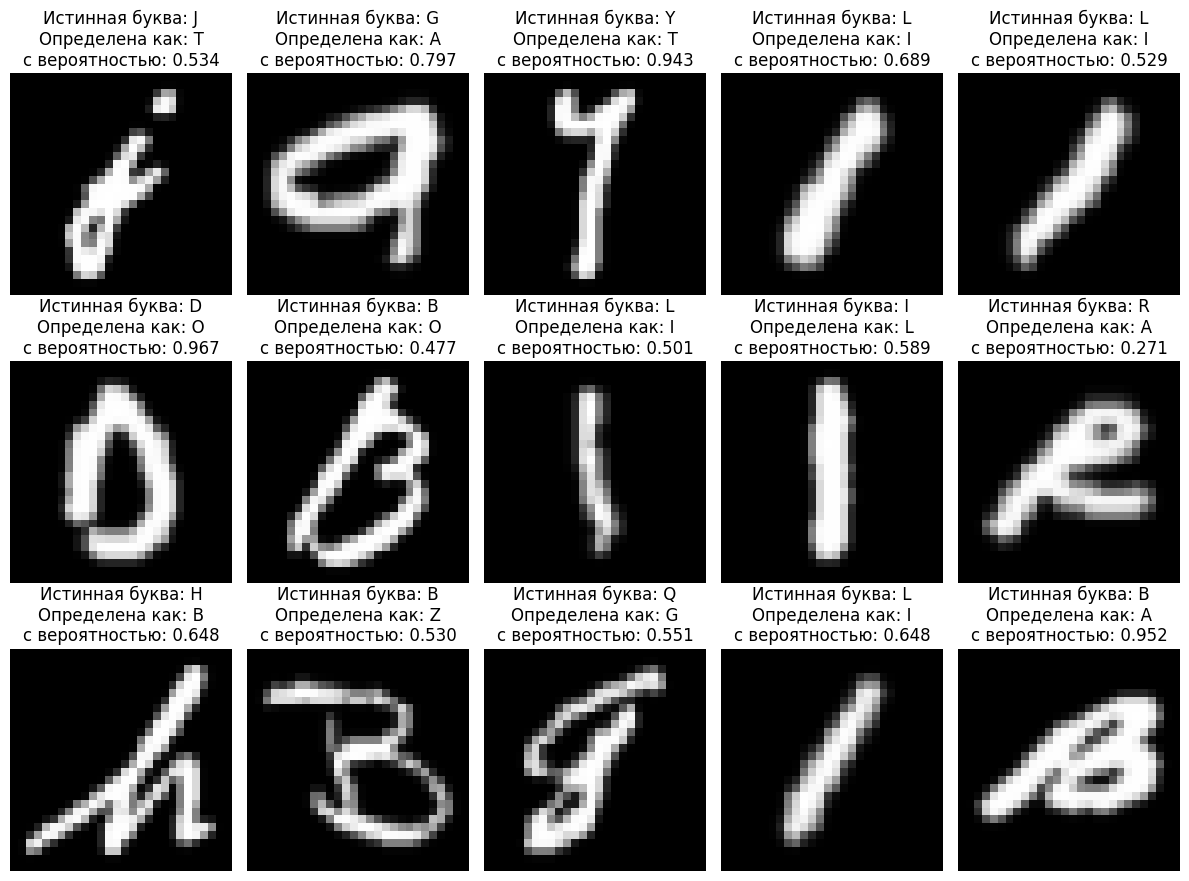

In [59]:
show_misclassified_from_raw(
    raw_test,
    labels_tf,
    preds_tf_d,
    conf_tf_d,
    random=True
)

По-человечески видно, что ошибки моделей во многих случаях вполне естественны. Даже глазом непросто понять, что это за буква в некоторых случаях. В других случаях и человек бы ошибся ровно так же, как и модель. Вообще почерк в датасете ужасный.

Функция сравнения confusion matrix

In [60]:
def compare_confusion_matrices(labels_pt, preds_pt, labels_tf, preds_tf):
    cm_pt = confusion_matrix(labels_pt, preds_pt, labels=range(26))
    cm_tf = confusion_matrix(labels_tf, preds_tf, labels=range(26))

    # Нормировка по строкам: доля ошибок внутри каждой истинной буквы
    cm_pt_norm = cm_pt / cm_pt.sum(axis=1, keepdims=True)
    cm_tf_norm = cm_tf / cm_tf.sum(axis=1, keepdims=True)

    # Разница: положительное = TF ошибается чаще, отрицательное = PT чаще
    diff = cm_tf_norm - cm_pt_norm

    fig, axes = plt.subplots(1, 3, figsize=(24, 7))

    im0 = axes[0].imshow(cm_pt_norm)
    axes[0].set_title("PyTorch confusion matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    im1 = axes[1].imshow(cm_tf_norm)
    axes[1].set_title("TensorFlow confusion matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")

    im2 = axes[2].imshow(diff)
    axes[2].set_title("Разница TF - PT")
    axes[2].set_xlabel("Predicted")
    axes[2].set_ylabel("True")

    for ax in axes:
        ax.set_xticks(range(26))
        ax.set_yticks(range(26))
        ax.set_xticklabels(letters, rotation=90)
        ax.set_yticklabels(letters)

    fig.colorbar(im0, ax=axes[0], fraction=0.046)
    fig.colorbar(im1, ax=axes[1], fraction=0.046)
    fig.colorbar(im2, ax=axes[2], fraction=0.046)

    plt.tight_layout()
    plt.show()

    return cm_pt_norm, cm_tf_norm, diff

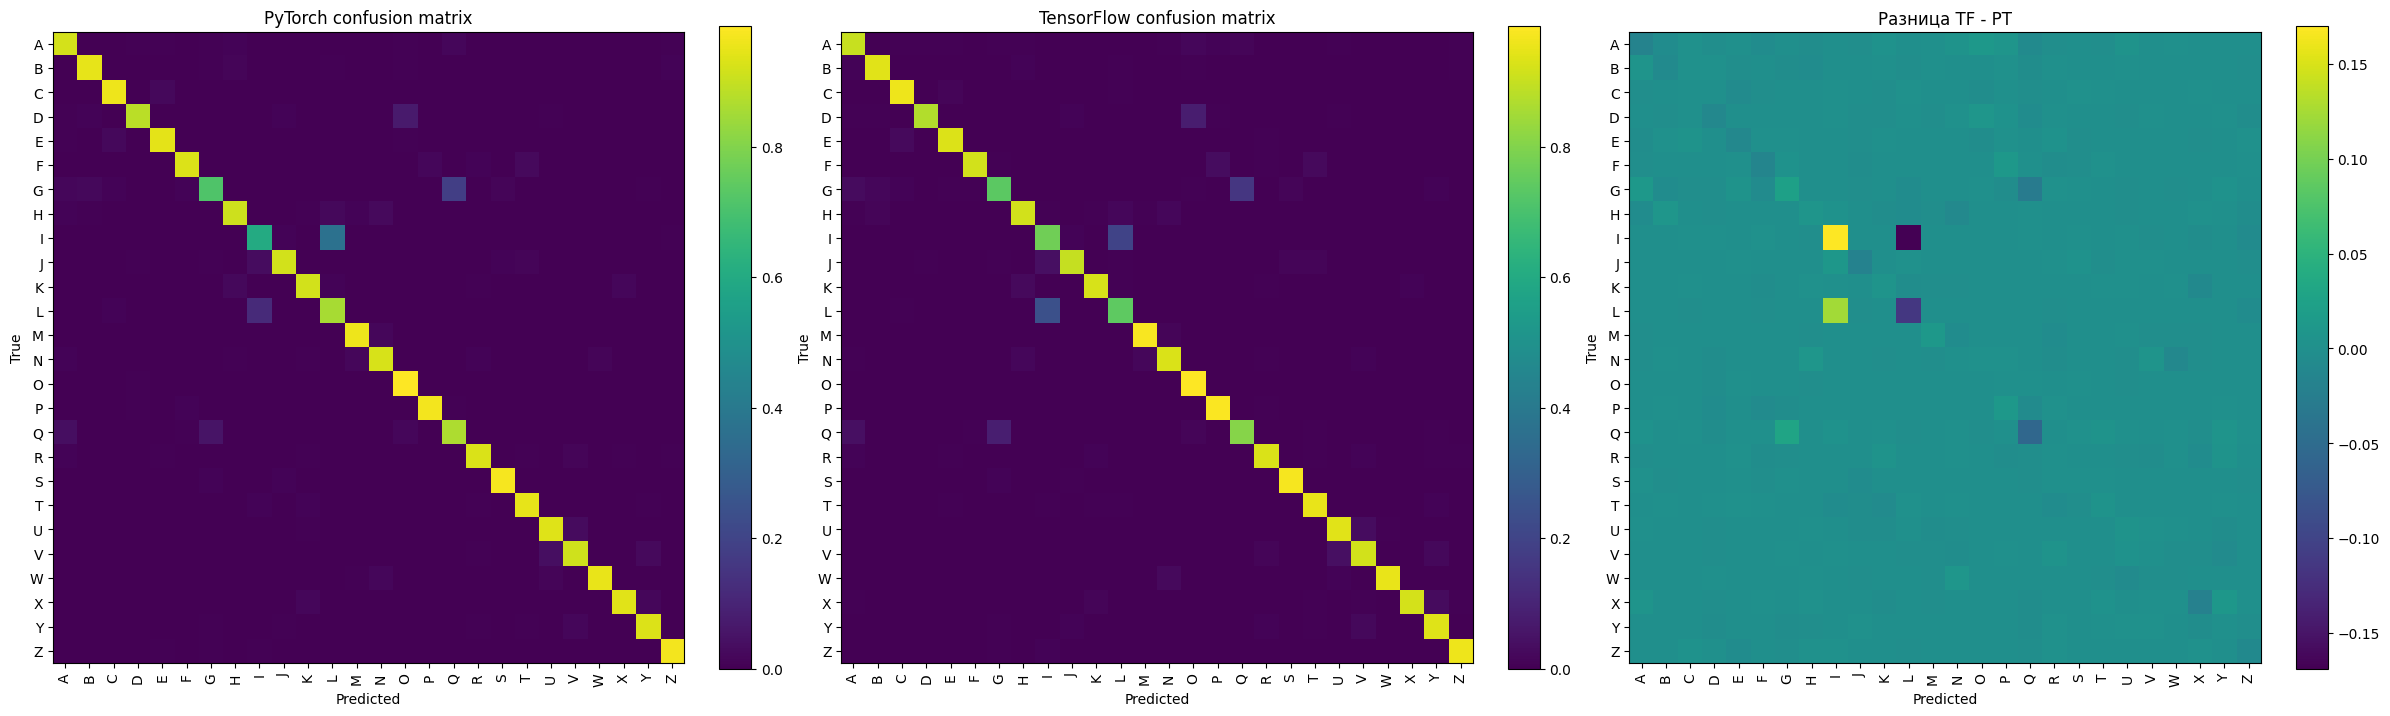

Максимальная разница: 0.170
Минимальная разница: -0.169


In [61]:
cm_pt_norm, cm_tf_norm, cm_diff = compare_confusion_matrices(
    labels_pt, preds_pt_d,
    labels_tf, preds_tf_d
)

print(f"Максимальная разница: {cm_diff.max():.3f}")
print(f"Минимальная разница: {cm_diff.min():.3f}")

Видно, что поведение моделей очень похоже. Большая часть разницы матриц около нуля, за исключением отдельных элементов. Модели ошибаются в разных буквах, но общая точность остается почти одинаковой

In [62]:
uploaded = files.upload()

Saving A.png to A.png
Saving C.png to C.png
Saving G.png to G.png
Saving I.png to I.png
Saving L.png to L.png
Saving O.png to O.png
Saving Q.png to Q.png
Saving W.png to W.png


In [63]:
# Предобработка изображений в отдельной функции
def preprocess_letter_image(filename, show_image=True):
    img = Image.open(filename).convert("L")
    img = img.resize((28, 28))

    img_array = np.array(img)

    if img_array.mean() > 127:
        img_array = 255 - img_array

    img_array = img_array.astype("float32") / 255.0

    if show_image:
        plt.figure(figsize=(3, 3))
        plt.imshow(img_array, cmap="gray")
        plt.axis("off")
        plt.show()

    # для MLP: (28, 28) -> (1, 28 * 28)
    img_flat = img_array.reshape(1, 784)

    return img_flat

In [64]:
# Функция классификации буквы
def predict_letter(filename, model, framework, device, show_image=True):
    x = preprocess_letter_image(filename, show_image=show_image)

    if framework == "pt":

        model.eval()

        x_tensor = torch.tensor(x, dtype=torch.float32)
        x_tensor = x_tensor.to(device)
        model = model.to(device)

        with torch.no_grad():
            logits = model(x_tensor)
            probs = torch.softmax(logits, dim=1)
            pred_idx = torch.argmax(probs, dim=1).item()
            confidence = torch.max(probs, dim=1).values.item()

    elif framework == "tf":

        logits = model(x, training=False)
        probs = tf.nn.softmax(logits, axis=1)

        pred_idx = int(tf.argmax(probs, axis=1).numpy()[0])
        confidence = float(tf.reduce_max(probs, axis=1).numpy()[0])

    else:
        raise ValueError("framework должен быть 'pt' или 'tf'")

    letter = chr(ord("A") + pred_idx)

    return {
        "letter": letter,
        "class_id": pred_idx,
        "confidence": confidence
    }

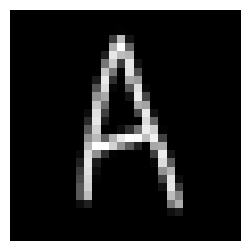

A.png                | PT: A (0.957) | TF: A (0.820)


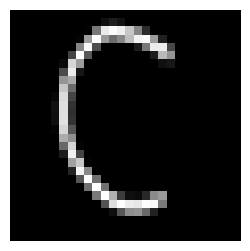

C.png                | PT: C (0.962) | TF: C (0.949)


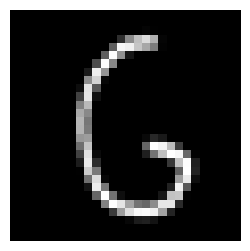

G.png                | PT: G (0.735) | TF: G (0.504)


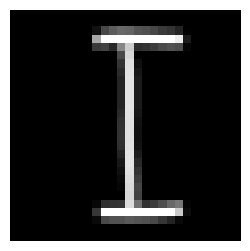

I.png                | PT: I (0.727) | TF: I (0.726)


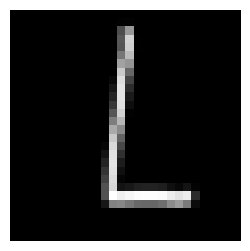

L.png                | PT: L (0.783) | TF: L (0.720)


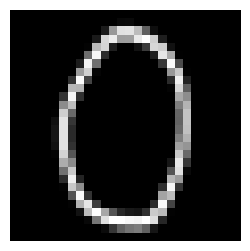

O.png                | PT: O (0.830) | TF: O (0.975)


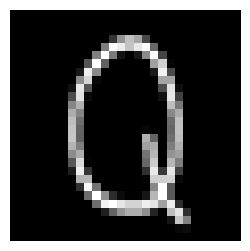

Q.png                | PT: Q (0.296) | TF: Q (0.652)


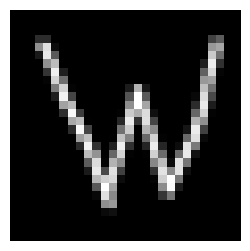

W.png                | PT: W (0.998) | TF: W (0.999)


In [65]:
for file in sorted(uploaded.keys()):
    pt_result = predict_letter(file, model_pt_dropout, "pt", device=device, show_image=True)
    tf_result = predict_letter(file, model_tf_dropout, "tf", device=device, show_image=False)

    print(f"{file:20s} | PT: {pt_result['letter']} ({pt_result['confidence']:.3f}) | TF: {tf_result['letter']} ({tf_result['confidence']:.3f})")

Для теста нарисованы буквы A, C, G, I, L, O, Q, W. Почерк старался держать аккуратным, но без усердия. Пришлось попробовать разную толщину линии. Предложенные буквы распознались без ошибок, но уверенность не везде высокая (например, Q, C, G).

Сложно было разобраться с поворотами букв. Сначала увидеть, что повернуты, потом найти правильное и рациональное преобразование. Самое неочевидное - необходимость поворачивать буквы еще раз в наборе для Tensorflow. Без этого этот фреймворк выдавал вообще не те буквы, что неудивительно, ведь обучался фактически на другом датасете.

Больше понравился Tensorflow, так как он более компактный по синтаксису, на мой взгляд более интуитивный, не требует ручного написания "обвязки" и быстрее обучается.

Если углубляться в эту задачу, я бы попробовал сделать модели на датасете исключительно на заглавных буквах (split='byclass' и дальше выбрать нужные). EMNIST Letters в используемой здесь редакции содержит как заглавные, так и строчные буквы, а определяем мы только заглавные. Строчные могут снижать точность.